# Run_Training Loader Check

This notebook only inspects the loader logic in `Run_Training.py`.

It does not start training, call `Trainer.train()`, or write checkpoints.


In [16]:
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_specdiff_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "Specular-Highlights" / "SpecDiff",
        Path.cwd().parent,
    ]
    for candidate in candidates:
        if (candidate / "Run_Training.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate SpecDiff/Run_Training.py from the current working directory.")


def tensor_stats(name: str, tensor: torch.Tensor) -> dict[str, object]:
    return {
        "name": name,
        "shape": tuple(tensor.shape),
        "dtype": str(tensor.dtype),
        "min": float(tensor.min()),
        "max": float(tensor.max()),
        "mean": float(tensor.mean()),
        "std": float(tensor.std(unbiased=False)),
        "has_nan": bool(torch.isnan(tensor).any()),
        "all_finite": bool(torch.isfinite(tensor).all()),
    }


def to_display_image(tensor: torch.Tensor) -> np.ndarray:
    array = tensor.detach().cpu().permute(1, 2, 0).numpy()
    if array.min() < 0.0:
        scale = max(abs(float(array.min())), abs(float(array.max())), 1e-6)
        array = 0.5 + array / (2.0 * scale)
    return np.clip(array, 0.0, 1.0)


def expected_target_label(task_mode: str) -> str:
    mapping = {
        "direct_diffuse": "trainer target = diffuse - glossy",
        "difference": "trainer target = glossy - diffuse",
        "diffuse_prior": "trainer target = diffuse",
    }
    return mapping[task_mode]


SPECDIFF_DIR = find_specdiff_dir()
if str(SPECDIFF_DIR) not in sys.path:
    sys.path.insert(0, str(SPECDIFF_DIR))

import Run_Training as rt

print(f"SpecDiff dir: {SPECDIFF_DIR}")


SpecDiff dir: /Users/27171653/Desktop/PhD/Highlight-modelling/Specular-Highlights/SpecDiff


In [17]:
DATASET_SOURCE = "local"  # "local" or "psd"
SPLIT = "train"
TASK_MODE = "direct_diffuse"  # "direct_diffuse", "difference", "diffuse_prior"
IMAGE_SIZE = 128
BATCH_SIZE = 2
SAMPLE_INDEX = 0
SUMMARY_SAMPLES = 8
SHUFFLE = False
NUM_WORKERS = 0

# Optional overrides. Leave as None to use Run_Training.py auto-discovery.
PSD_ROOT = None
DATA_ROOT = None
GLOSSY_DIR = None
DIFFUSE_DIR = None


In [18]:
loader, info = rt.build_data_loader(
    dataset_source=DATASET_SOURCE,
    psd_root=Path(PSD_ROOT).expanduser().resolve() if PSD_ROOT else None,
    data_root=Path(DATA_ROOT).expanduser().resolve() if DATA_ROOT else None,
    split=SPLIT,
    glossy_dir=GLOSSY_DIR,
    diffuse_dir=DIFFUSE_DIR,
    image_size=IMAGE_SIZE,
    task_mode=TASK_MODE,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    num_workers=NUM_WORKERS,
)

dataset = loader.dataset
sample = dataset[SAMPLE_INDEX]
condition = sample[:3]
paired_output = sample[3:]
trainer_target =  paired_output - condition
batch = next(iter(loader))

assert sample.ndim == 3 and sample.shape[0] == 6, f"Expected [6, H, W], got {tuple(sample.shape)}"
assert batch.ndim == 4 and batch.shape[1] == 6, f"Expected [B, 6, H, W], got {tuple(batch.shape)}"

print("Loader info:")
pprint(info)
print()
print(f"dataset length: {len(dataset)}")
print(f"batch shape: {tuple(batch.shape)}")
print(f"task mode: {TASK_MODE}")
print(expected_target_label(TASK_MODE))
print()
pprint(tensor_stats("sample", sample))
pprint(tensor_stats("condition", condition))
pprint(tensor_stats("paired_output", paired_output))
pprint(tensor_stats("trainer_target", trainer_target))


Loader info:
{'data_root': '/Users/27171653/Desktop/PhD/Highlight-modelling/Specular-Highlights/data',
 'dataset_source': 'local',
 'split_root': '/Users/27171653/Desktop/PhD/Highlight-modelling/Specular-Highlights/data/train'}

dataset length: 50
batch shape: (2, 6, 128, 128)
task mode: direct_diffuse
trainer target = diffuse - glossy

{'all_finite': True,
 'dtype': 'torch.float32',
 'has_nan': False,
 'max': 0.6549019813537598,
 'mean': 0.028913432732224464,
 'min': 0.0,
 'name': 'sample',
 'shape': (6, 128, 128),
 'std': 0.072367824614048}
{'all_finite': True,
 'dtype': 'torch.float32',
 'has_nan': False,
 'max': 0.6549019813537598,
 'mean': 0.026868155226111412,
 'min': 0.0,
 'name': 'condition',
 'shape': (3, 128, 128),
 'std': 0.06821434944868088}
{'all_finite': True,
 'dtype': 'torch.float32',
 'has_nan': False,
 'max': 0.27843138575553894,
 'mean': 0.03095870651304722,
 'min': 0.0,
 'name': 'paired_output',
 'shape': (3, 128, 128),
 'std': 0.07624068111181259}
{'all_finite': Tr

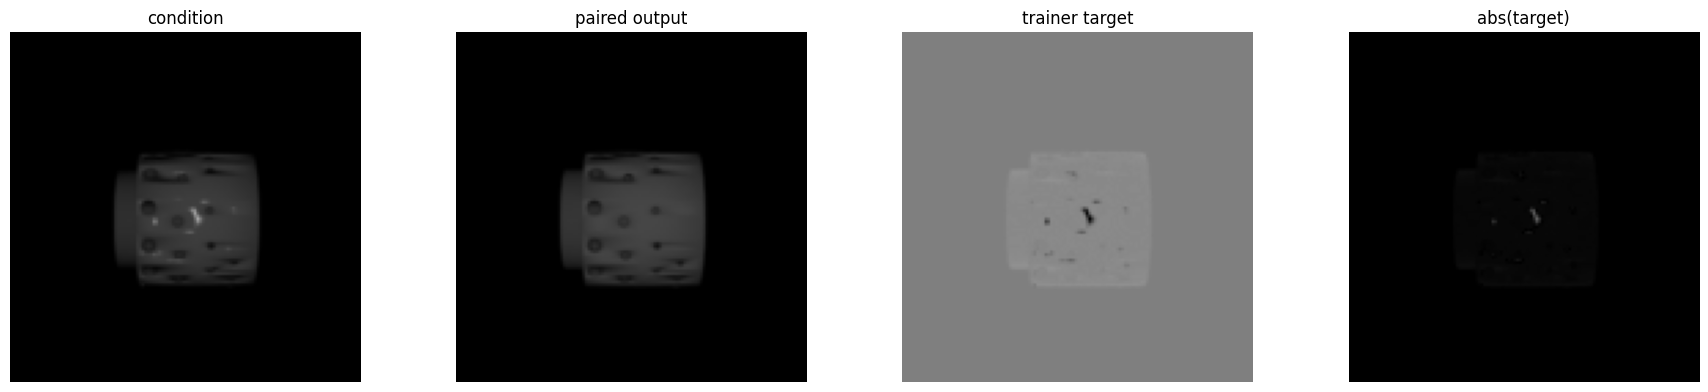

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(to_display_image(condition))
axes[0].set_title("condition")
axes[1].imshow(to_display_image(paired_output))
axes[1].set_title("paired output")
axes[2].imshow(to_display_image(trainer_target))
axes[2].set_title("trainer target")
axes[3].imshow(to_display_image(trainer_target.abs()))
axes[3].set_title("abs(target)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


In [20]:
summary_rows = []
for idx in range(min(SUMMARY_SAMPLES, len(dataset))):
    current = dataset[idx]
    current_condition = current[:3]
    current_paired_output = current[3:]
    current_target = current_paired_output - current_condition
    summary_rows.append(
        {
            "idx": idx,
            "all_finite": bool(torch.isfinite(current).all()),
            "condition_mean": float(current_condition.mean()),
            "paired_mean": float(current_paired_output.mean()),
            "target_abs_mean": float(current_target.abs().mean()),
            "target_abs_max": float(current_target.abs().max()),
        }
    )

summary_rows


[{'idx': 0,
  'all_finite': True,
  'condition_mean': 0.026868155226111412,
  'paired_mean': 0.03095870651304722,
  'target_abs_mean': 0.004681276623159647,
  'target_abs_max': 0.3764705955982208},
 {'idx': 1,
  'all_finite': True,
  'condition_mean': 0.024995213374495506,
  'paired_mean': 0.029803350567817688,
  'target_abs_mean': 0.005308383610099554,
  'target_abs_max': 0.33725491166114807},
 {'idx': 2,
  'all_finite': True,
  'condition_mean': 0.029602771624922752,
  'paired_mean': 0.03397456184029579,
  'target_abs_mean': 0.005044376477599144,
  'target_abs_max': 0.3764705955982208},
 {'idx': 3,
  'all_finite': True,
  'condition_mean': 0.029086003080010414,
  'paired_mean': 0.03367776423692703,
  'target_abs_mean': 0.00491297198459506,
  'target_abs_max': 0.3764705955982208},
 {'idx': 4,
  'all_finite': True,
  'condition_mean': 0.024298453703522682,
  'paired_mean': 0.029234884306788445,
  'target_abs_mean': 0.005204982589930296,
  'target_abs_max': 0.19999998807907104},
 {'idx'